### Задание



1. Выберите любой из 6-ти рядов из материалов (интереснее работать с рядами, у которых выраженная сезонность).
2. Постройте модель ARIMA для этого ряда, аналогично материалам лекции, с поиском оптимальных параметров.
3. Постройте график остатков предсказания ряда.
4. Дополнительное задание: постройте предсказание ряда с помощью классического ML. Поэкспериментируйте с фичами ряда (лагами).


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm
import statsmodels.tsa.api as smt

## Подготовка данных и функций

### Для модели ARIMA

In [4]:
airlines_passengers = pd.read_csv("/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Модели ARMA и ARIMA/Материалы к занятию «Знакомство с временными рядами»/Series/international-airline-passengers.csv")
airlines_passengers

,Month,Count
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


#### Визуализация

In [2]:
def plot_(model,series,title):
    with plt.style.context('bmh'):
        plt.figure(figsize=(8, 8))
        if model == None:
            plt.plot(series, color='blue', linewidth='2', label='Real')
        else:
            plt.plot(model, color='red', linewidth='2', label='Pred')
            plt.plot(series, color='blue', linewidth='2', label='Real')
        plt.legend()
        plt.title(f'{title}')

    plt.show()

In [23]:
def test_stationarity(series):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [31]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1) ## виртуальная сетка таблицы
        ## расположение графиков внутри виртуальной сетки
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2) 
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or') ## исходный график
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05) ## график автокрреляции
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05) ## график частичной автокорреляции
        sm.qqplot(y, line='s', ax=qq_ax) ## график квантилей
        
        plt.show()
    return

#### Функция для подбора параметров

In [10]:

def search_param_ARIMA (series):
    best_aic = np.inf
    best_param = None
    best_model = None

    for i in range (7):
        for j in range(7):
            for d in range(7):
                try:
                    model = ARIMA(series,order=(i,d,j),trend='n').fit()
                    model_aic = model.aic
                    if model_aic < best_aic:
                        best_aic = model_aic
                        best_param = (i,d,j)
                        best_model= model
                except: continue

    print(f'Информационный критерий - {best_aic}, параметры - {best_param}')
    return best_model



#### Функция для предсказания ряда

In [21]:
from statsmodels.graphics.tsaplots import plot_predict

def plot_pred(series):
    with plt.style.context(style='bmh'):
        model = search_param_ARIMA(series=series)
        plt.figure(figsize=(14,8))
        ax = plt.axes()
        plot_predict(model, 1, len(series)+20, ax=ax)
        plt.plot(series, color='red', label='Series')
        plt.legend()
        plt.show()
	


#### График остатков

In [25]:
def plot_resid(series):
    model = search_param_ARIMA(series=series)
    
    tsplot(y=model.resid)

### С помощью классического ML

В рамках обучения модели с помощью классического машинного обучения будем использовать три модели - модель линейной регрессии, деревья решений и градиентный бустинг

In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

#### Подготовка данных

In [101]:
airlines_passengers['Month'] = pd.to_datetime(airlines_passengers['Month'])

In [111]:
X = np.array(airlines_passengers['Month'].map(lambda x: x.toordinal())).reshape(-1, 1) ## преобразуем в порядковый номер месяца
Y = np.array(airlines_passengers['Count'])

In [112]:
X_train,X_test,y_train,y_test = train_test_split(X,Y ,test_size=0.2,random_state=42)


#### Поиск параметров моделей

In [133]:
param_tree = GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [3,5,7,9,11,13,15], 'min_samples_split':[1,5,10,15,20,50,100], 'criterion':['friedman_mse', 'poisson', 'absolute_error', 'squared_error']})
param_tree.fit(X_train,y_train)
print(f'Лучшие параметры деревьев решений {param_tree.best_params_}')

Лучшие параметры деревьев решений {'criterion': 'poisson', 'max_depth': 9, 'min_samples_split': 5}


In [134]:
param_grad_boost = GridSearchCV(estimator=GradientBoostingRegressor(), 
                                param_grid= {'n_estimators':[5,10,25,50,100],
                                            'learning_rate':[0.01,0.1,1],
                                            'min_samples_split':[1,5,10,15,20],},
                                            cv=5,)
param_grad_boost.fit(X_train,y_train)
print(f'Лучшие параметры градиентного бустинга f{param_grad_boost.best_params_}')

Лучшие параметры градиентного бустинга f{'learning_rate': 0.1, 'min_samples_split': 5, 'n_estimators': 100}


In [131]:
def model_ML(model_name,X,X_ts,y,y_ts):
    if model_name == 'Linear Regression':
        model = LinearRegression()
    elif model_name == 'Decision Tree':
        model = DecisionTreeRegressor(max_depth=9, random_state=10, min_samples_split=5,criterion='poisson')
    elif model_name == 'Gradient Boosting':
        model=GradientBoostingRegressor(learning_rate=0.1,min_samples_split=5,n_estimators=100)


    model.fit(X, y)  
    y_pred = model.predict(X_ts) 
    score = model.score(X_ts, y_ts)
    print(f'Точность модели - {score:.4f}')
    return model

#### Визуализация

In [149]:

def plot_pred_ML(series, model, n_steps=10):
    with plt.style.context(style='bmh'):
        plt.figure(figsize=(14, 8))

        # Собираем целевую переменную и признаки и переводим в корректный формат
        X = series['Month'].map(lambda x: x.toordinal()).values.reshape(-1, 1)
        y_true = series['Count'].values
        y_pred = model.predict(X)

        ### Прогноз вперед
        last_date = series['Month'].max() ## Последнее значение месяца (последний месяц)
        future_dates = pd.date_range(start=last_date, periods=n_steps+1, freq="MS")[1:] ## ищем 10 точек вперед, на которых будем предсказывать

        ## Преобразуем для подачи в модель
        X_future = future_dates.map(lambda x: x.toordinal()).values.reshape(-1, 1)
        y_future = model.predict(X_future)

        
        plt.plot(series['Month'], y_true, color='red', label='Истинный ряд')
        plt.plot(series['Month'], y_pred, color='blue', label='Предсказания модели')
        plt.plot(future_dates, y_future, color='green', linestyle="--", label=f'Прогноз на {n_steps} шагов')

        plt.legend()
        plt.show()

Точность модели - 0.9116


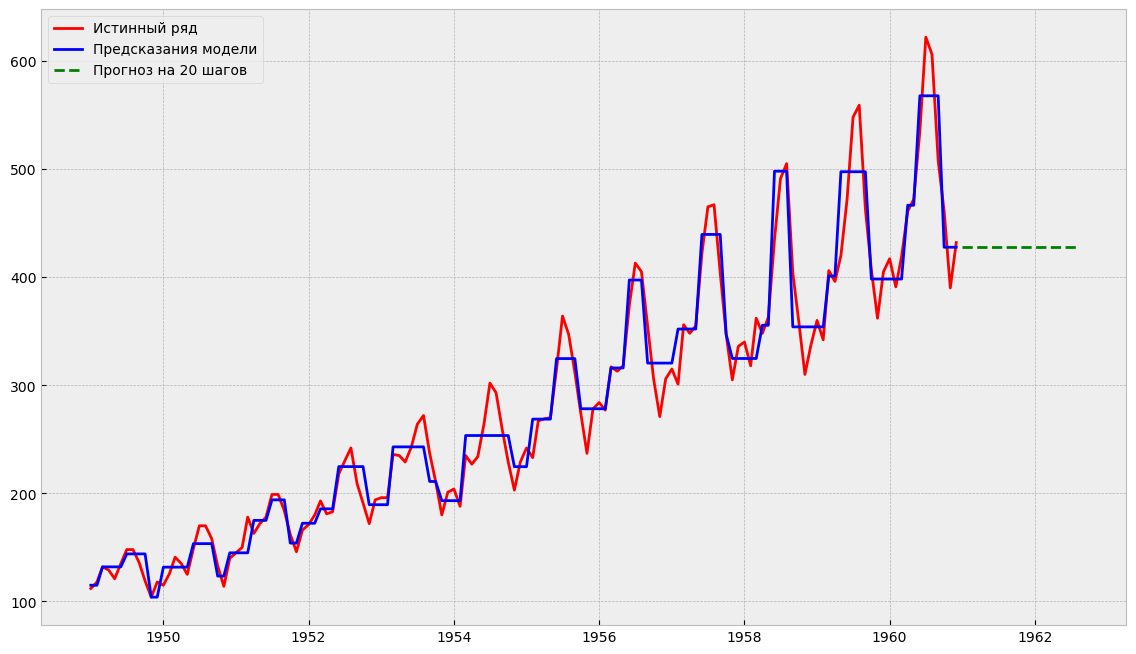

In [150]:
plot_pred_ML(model=model_ML('Decision Tree',X_train,X_test,y_train,y_test),series=airlines_passengers,n_steps=20)

## Реализация

### C помощью модели ARIMA

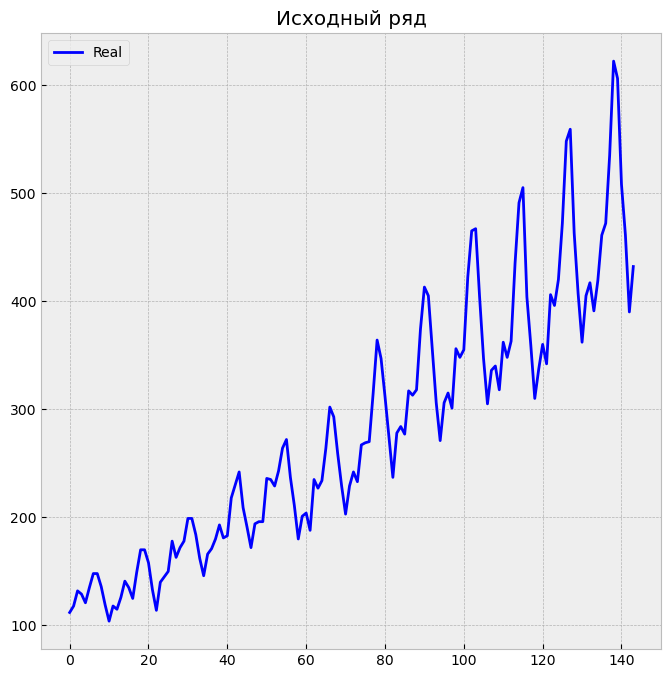

In [33]:
plot_(model=None,series=airlines_passengers['Count'],title='Исходный ряд')

In [34]:
search_param_ARIMA(airlines_passengers['Count'])

Информационный критерий - 1310.451468565713, параметры - (6, 1, 6)


Информационный критерий - 1310.451468565713, параметры - (6, 1, 6)


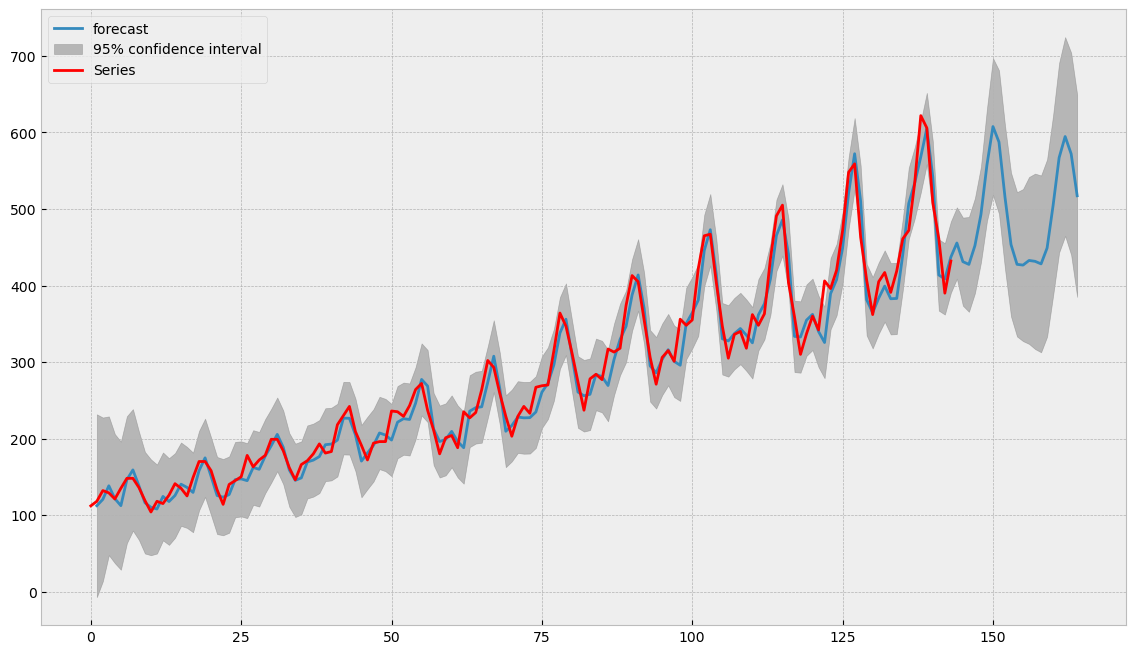

In [35]:
plot_pred(series=airlines_passengers['Count'])

Информационный критерий - 1310.451468565713, параметры - (6, 1, 6)
Results of Dickey-Fuller Test:
Test Statistic                  -4.025004
p-value                          0.001285
#Lags Used                      11.000000
Number of Observations Used    132.000000
Critical Value (1%)             -3.480888
Critical Value (5%)             -2.883697
Critical Value (10%)            -2.578586
dtype: float64


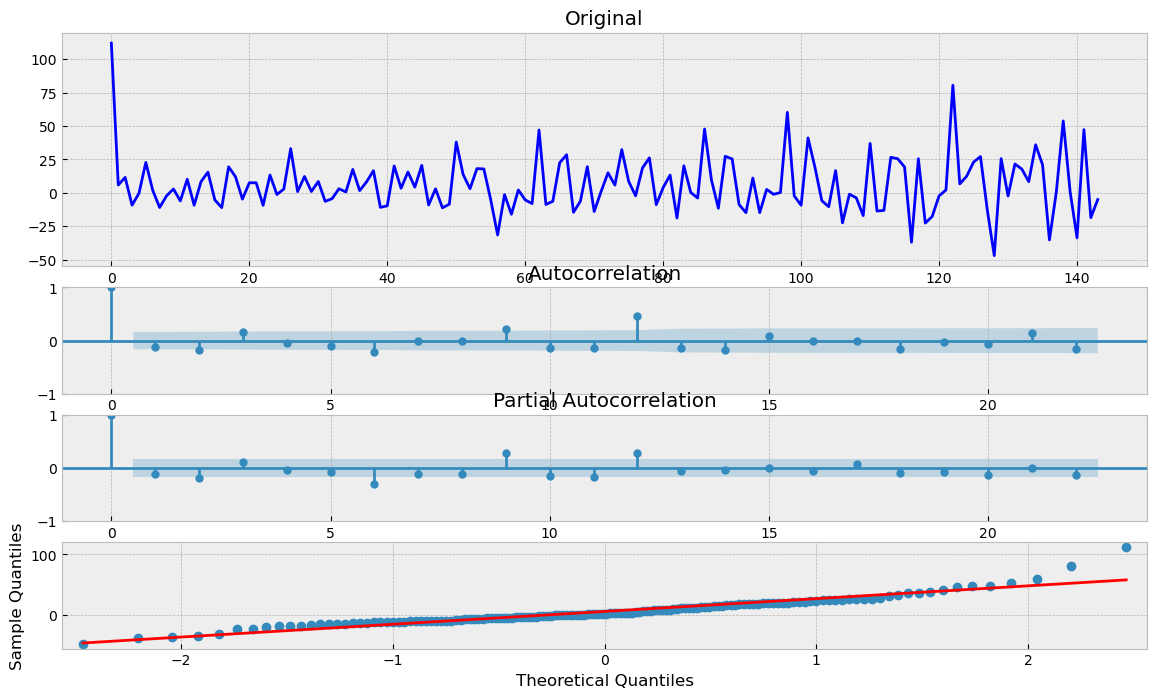

In [36]:
plot_resid(airlines_passengers['Count'])

#### Вывод
Модель ARIMA хорошо эсктраполирует данные на 20 шагов вперед, учитывает тренд и сезонность исходного ряда. График остатков и тест Дики-Фуллера так же демонстрируют то, что модель хорощо справилась с прогнозом, так как ряд стационарен

### С помощью классического ML

#### Выбор лучшей модели для обучения

Точность модели - 0.8420


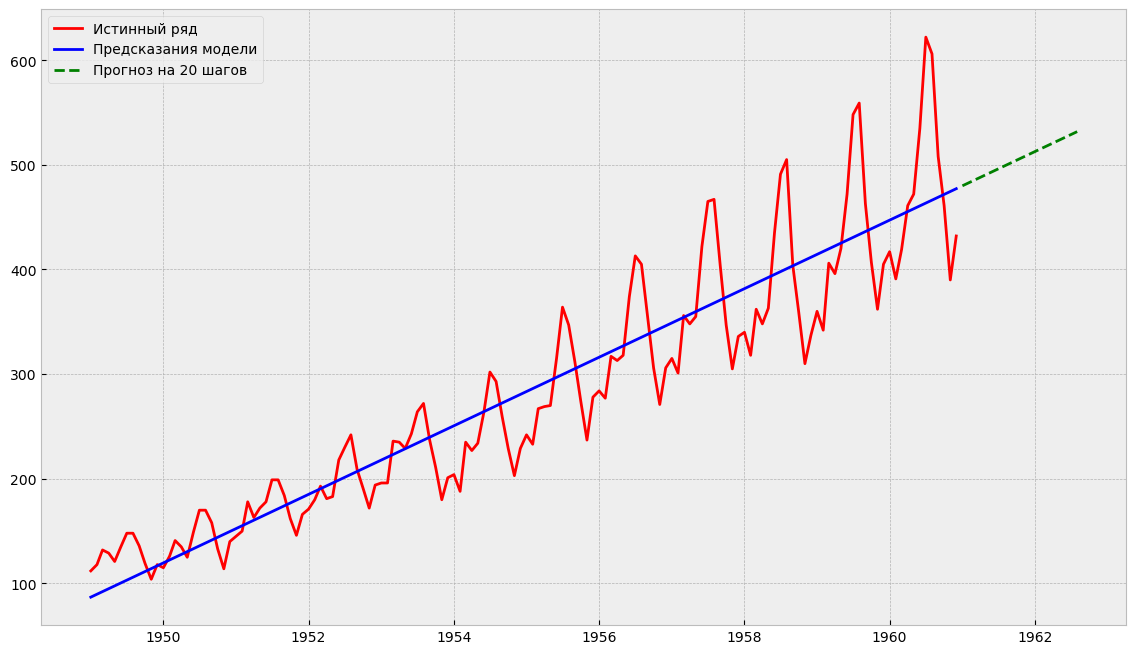

In [152]:
plot_pred_ML(model=model_ML('Linear Regression',X_train,X_test,y_train,y_test),series=airlines_passengers,n_steps=20)

Точность модели - 0.9116


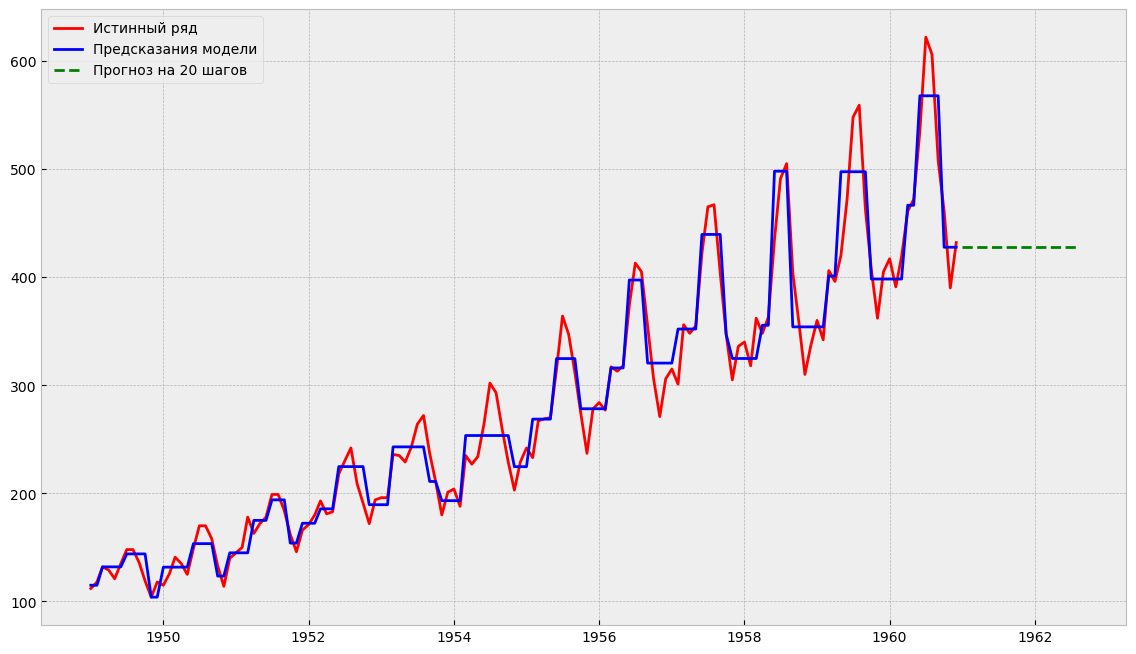

In [153]:
plot_pred_ML(model=model_ML('Decision Tree',X_train,X_test,y_train,y_test),series=airlines_passengers,n_steps=20)

Точность модели - 0.8897


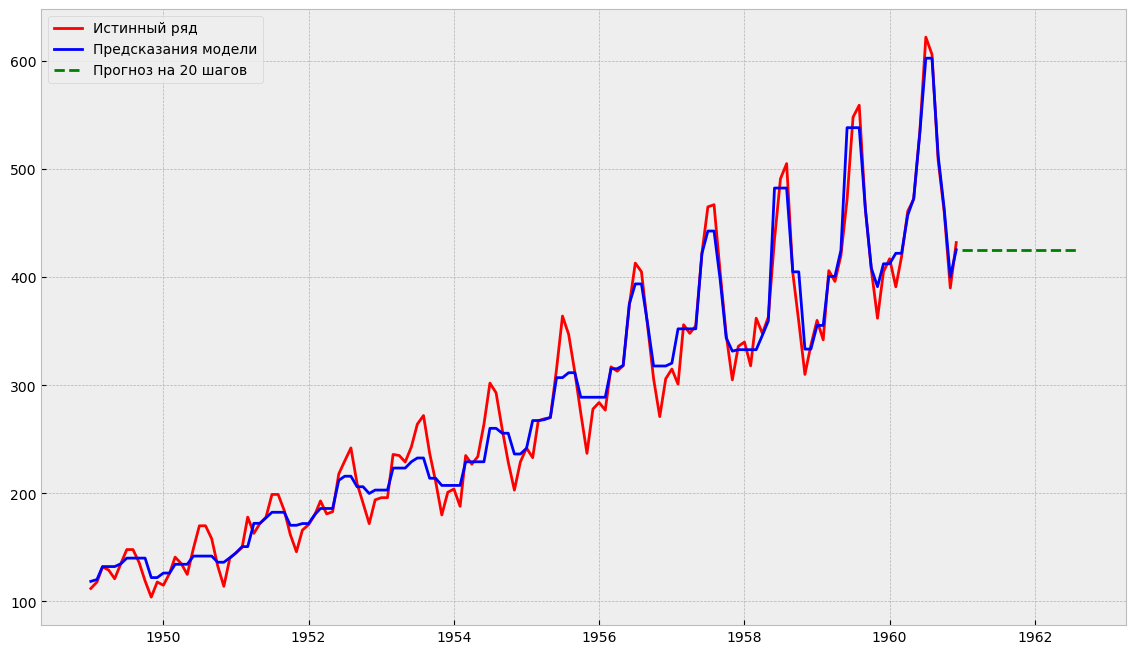

In [155]:
plot_pred_ML(model=model_ML('Gradient Boosting',X_train,X_test,y_train,y_test),series=airlines_passengers,n_steps=20)

Модель линейной регрессии не учитывает сезонность ряда, лишь продлевает его по найденному тренду, модели деревьев решений и градиентного бустинга, хоть и учитывают сезонность и тренд на обучающей и тестовой выборках и хорошо интерполируют данные внутри ряда, но не могут экстрополировать ряд во времени на точки, которые выходят за пределы тестовой выборки, в связи с чем не предсказывают ряд, а выходят на плато. Это происходит потому, что все новые точки попадают в один терминальный узел, где прогнозом будет среднее значение меток

Для того, чтобы предсказания не выходили на плато, можно добавить дополнительные признаки для ряда - лаги. Лаги дают модели контекст предыдущих значений, чтобы она могла понимать тренд, повторять сезонность, делать прогноз на несколько шагов вперёд.

In [196]:
def create_lag_features(series, n_lags):
    df = series.copy()
    for lag in range(1, n_lags+1):
        df[f'lag_{lag}'] = df['Count'].shift(lag)
    df = df.dropna().reset_index(drop=True)
    return df

In [227]:
n_lags = 10
data_lags = create_lag_features(series=airlines_passengers, n_lags=n_lags)
X_lag = data_lags[[f'lag_{i}' for i in range(1, n_lags+1)]].values
y_lag = data_lags['Count'].values


In [228]:
X_train_lag,X_test_lag,y_train_lag,y_test_lag = train_test_split(X_lag,y_lag,random_state=42,test_size=0.2)

In [229]:
def model_with_lags(model, series, n_lags, n_steps=20):

    history = series['Count'].values[-n_lags:].tolist() ## показываем последние значения 
    predictions = []

    for _ in range(n_steps):
        X_input = np.array(history[-n_lags:]).reshape(1, -1) ## на каждом предсказании будем брать  предыдущие значения внутри размера лага и скармливать их модели
        y_next = model.predict(X_input)[0]
        predictions.append(y_next)
        history.append(y_next) ## добавляем предсказание

    future_dates = pd.date_range(start=series['Month'].max(), periods=n_steps+1, freq="MS")[1:] ## будущие значения
    future_dates = pd.DataFrame({"Month": future_dates, "Forecast": predictions})

    plt.figure(figsize=(14, 8))
    plt.plot(series['Month'], series['Count'], color='red', label='Истинный ряд')
    plt.plot(future_dates['Month'], future_dates['Forecast'], color='green', linestyle="--", label='Рекурсивный прогноз с лагами')

    plt.legend()
    plt.show()




Точность модели - 0.9249


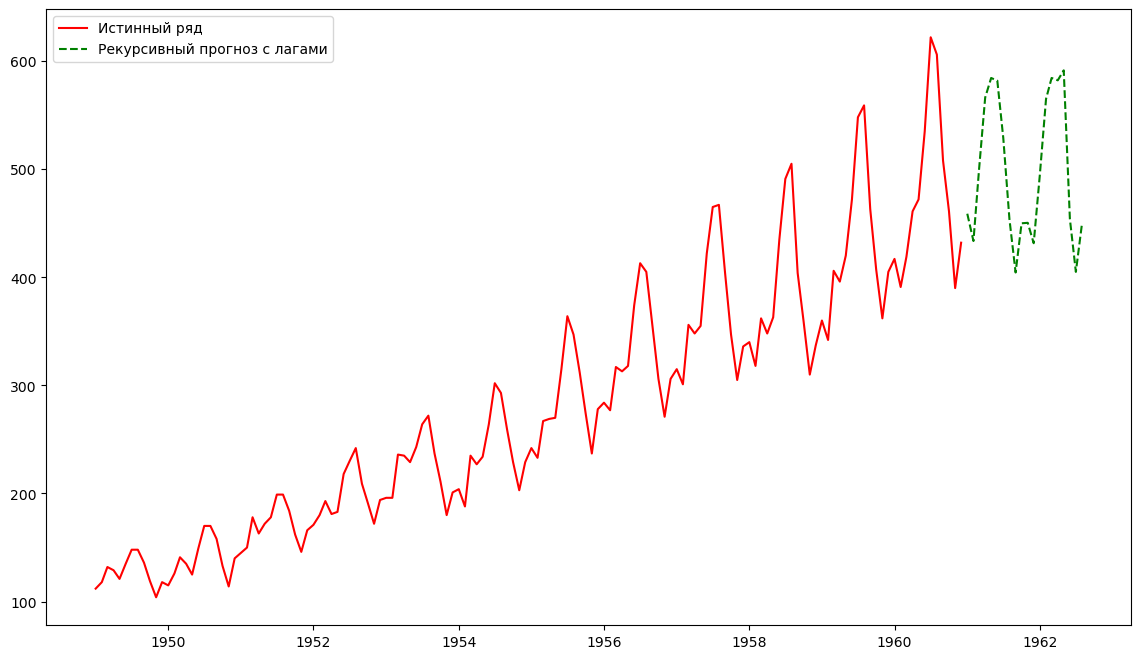

In [230]:
model_with_lags(model=model_ML('Gradient Boosting',X_train_lag,X_test_lag,y_train_lag,y_test_lag),series=airlines_passengers,n_lags=10,n_steps=20)

Точность модели - 0.8942


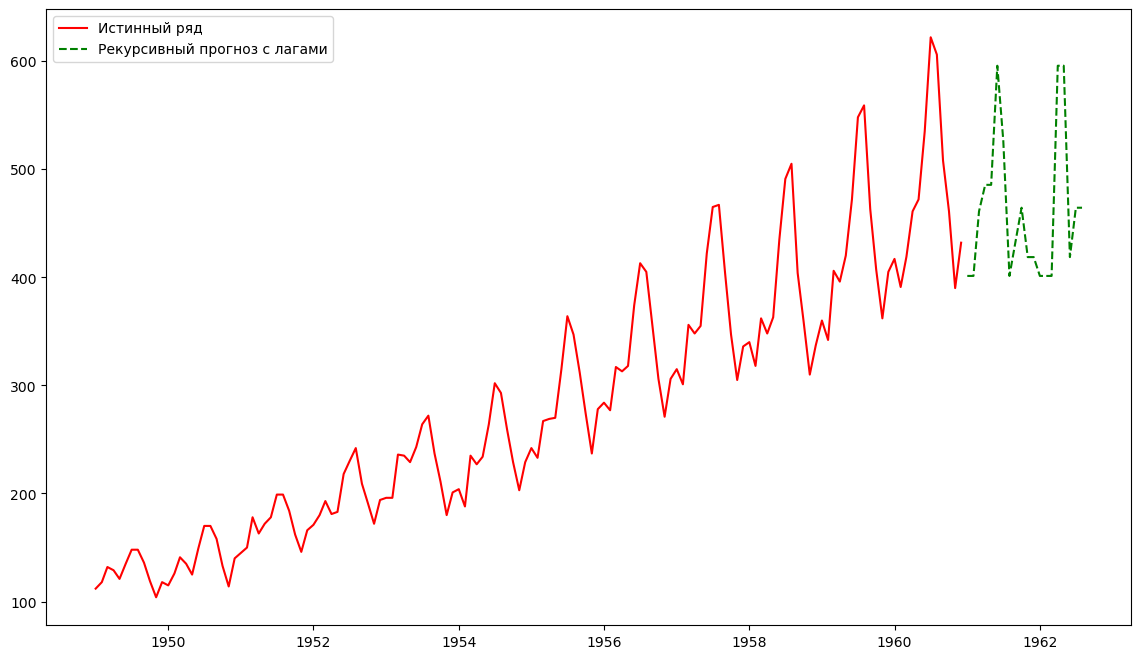

In [231]:
model_with_lags(model=model_ML('Decision Tree',X_train_lag,X_test_lag,y_train_lag,y_test_lag),series=airlines_passengers,n_lags=10,n_steps=20)

Точность модели - 0.9407


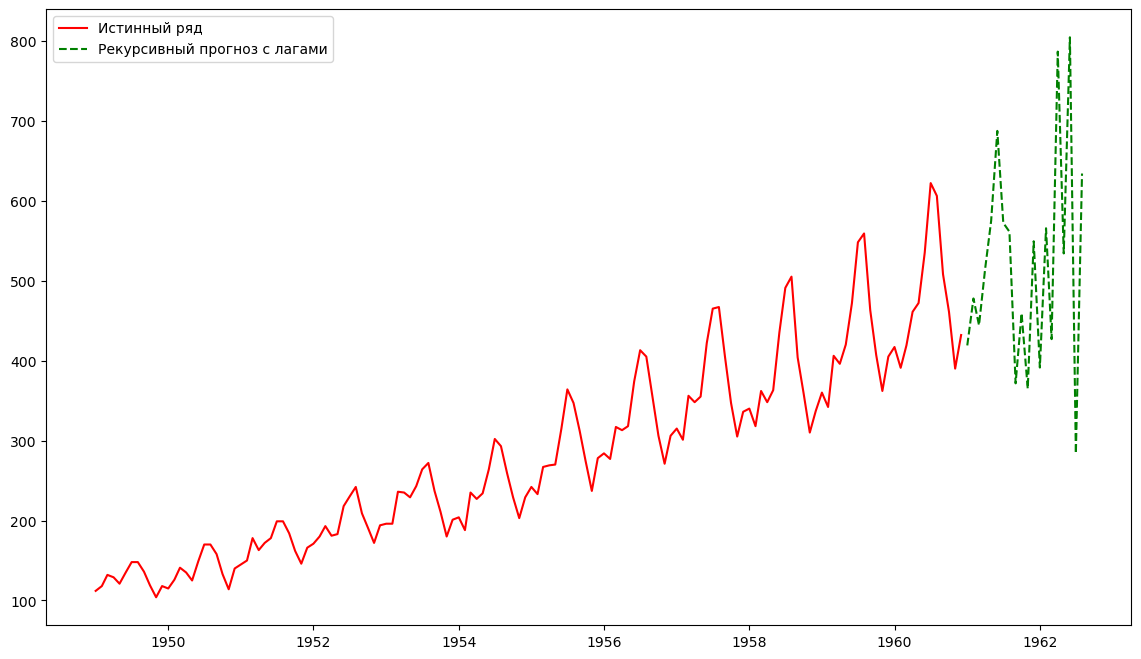

In [232]:
model_with_lags(model=model_ML('Linear Regression',X_train_lag,X_test_lag,y_train_lag,y_test_lag),series=airlines_passengers,n_lags=10,n_steps=20)

Все три модели стали очень хорошо предсказывать ряд, но лучше всего с этим справилась модель линейной регрессии. Вероятнее всего, она стала вести себя как модель авторегрессии, которая берет предыдущее значение и добавляет к нему шум

#### Вывод
Модели стали лучше предсказывать ряд после того, как были добавлены дополнительные фичи - лаги (предыдущие значения ряда), на которых модели стали понимать, как вел себя ряд определенное количество шагов назад, и начали учитывать сезонность ряда, а не просто выходить на плато, как модели DT и GB, или идти по тренду, как модель LR